# Advanced Project 🔴 - Underfit vs Overfit: A California Housing Autopsy

> **MLCourse · Machine Learning · supervised · regression**

### What you'll learn

1. Deliberately building an **underfit** (depth=1), a **balanced** (depth=3),
   and an **overfit** (unpruned) regressor on the same data.
2. Reading train/test R² side-by-side as a bias-variance diagnosis.
3. Comparing actual-vs-predicted scatters for all three, panel by panel.
4. Using **cost-complexity pruning** to land on the sweet spot automatically.

### Setup cell: libraries, reproducibility, plot styling (run me first).


In [ ]:
try:  # inline plotting inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain script mode → nothing to configure
    pass

import numpy as np                  # vector maths
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # styling layer

from sklearn.model_selection import train_test_split, cross_val_score   # split + CV
from sklearn.tree import DecisionTreeRegressor                          # the autopsy subject
from sklearn.metrics import mean_squared_error, r2_score                # metrics

np.random.seed(42)                  # reproducibility
sns.set_theme()                     # consistent look
plt.rcParams["figure.dpi"] = 100    # light crisp figures


### 1. Data: fixed 5,000-row sample of California housing

Same recipe as the workflow notebook so results are comparable across chapters.
Target = median house value per census block (in \$100k units, capped at 5.0).

In [2]:
from pathlib import Path  # portable paths

def find_data_dir():
    # Climb from the running folder up to '02_machine_learning', then into 'data'.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # ascend one directory per loop
    return here / "data"

DATA_DIR = find_data_dir()          # shared course data folder

def load_california():
    # Cache-once helper: derive the CSV from sklearn's loader only on first use.
    csv_path = DATA_DIR / "california_housing.csv"
    if not csv_path.exists():       # build cache once for the whole course
        from sklearn.datasets import fetch_california_housing   # bundled with scikit-learn
        frame = fetch_california_housing(as_frame=True).frame    # features + target together
        frame.to_csv(csv_path, index=False)                  # persist for every later notebook
        print(f"Created cache -> {csv_path}")
    return pd.read_csv(csv_path)

housing_full = load_california()
housing = housing_full.sample(n=5000, random_state=42).reset_index(drop=True)  # identical sample everywhere

target = "MedHouseVal"              # $100k units; visible cap at 5.0 (= $500k policy limit)
features = [c for c in housing.columns if c != target]

X_train, X_test, y_train, y_test = train_test_split(
    housing[features], housing[target],
    test_size=0.2, random_state=42,                      # fixed shuffle → same split each run
)
print(f"train {X_train.shape} | test {X_test.shape}")

train (4000, 8) | test (1000, 8)


### 2. Three deliberate patients: depth=1, depth=3, unpruned

- `depth=1` - ONE split. Massive **bias**: can't represent any curvature.
- `depth=3` - up to 8 leaves. Usually the honest sweet spot for this data.
- unpruned - grows till leaves are tiny. Massive **variance**: memorises noise.

We record train AND test R²/RMSE for each and read the pattern:
underfit → both low (and close); overfit → train ≈ 1, test far lower.

In [3]:
candidates = {
    "underfit  (depth=1)": DecisionTreeRegressor(max_depth=1, random_state=42),
    "sweet-spot(depth=3)": DecisionTreeRegressor(max_depth=3, random_state=42),
    "overfit   (None)  ": DecisionTreeRegressor(random_state=42),      # no limits at all
}

rows = []
fitted = {}
for label, mdl in candidates.items():
    mdl.fit(X_train, y_train)                                          # same data, three capacities
    fitted[label] = mdl                                                # keep for plotting below
    for part, X_, y_ in [("train", X_train, y_train), ("test ", X_test, y_test)]:
        pred = mdl.predict(X_)
        rows.append({
            "model": label, "split": part.strip(),
            "R2": r2_score(y_, pred),                                  # variance explained
            "RMSE": np.sqrt(mean_squared_error(y_, pred)),             # $100k-unit miss
            "leaves": mdl.get_n_leaves(),                              # model complexity
        })

audit = pd.DataFrame(rows).set_index(["model", "split"]).round(3)
audit

R2   RMSE  leaves
model               split                      
underfit  (depth=1) train  0.307  0.953       2
                    test   0.283  0.984       2
sweet-spot(depth=3) train  0.542  0.775       8
                    test   0.521  0.805       8
overfit   (None)    train  1.000  0.000    3875
                    test   0.441  0.869    3875

### Visual autopsy: actual-vs-predicted, side by side

Each dot should sit on the dashed y=x line. Watch the failure modes differ:
the underfit tree's predictions collapse onto ~2 horizontal bands (it only
has two output values!); the overfit tree hugs the line on train but sprays
vertically on test.

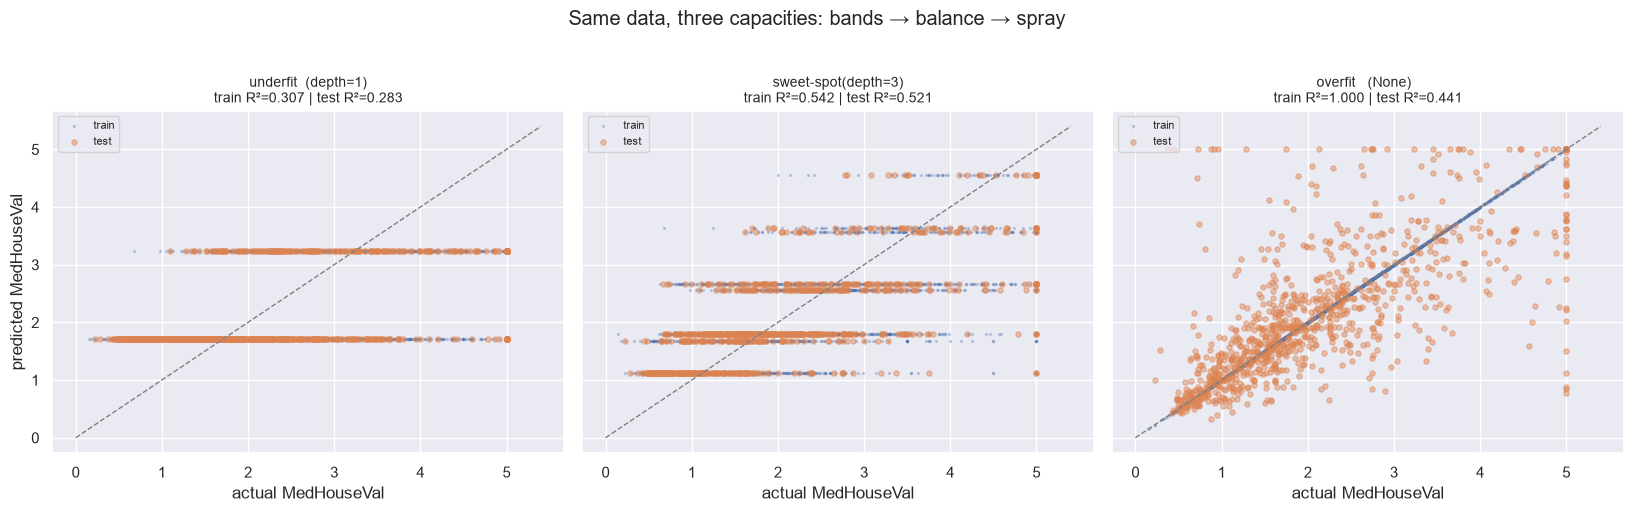

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5), sharey=True, sharex=True)
for ax, (label, mdl) in zip(axes, fitted.items()):
    tr_r2 = r2_score(y_train, mdl.predict(X_train))                    # annotate both scores
    te_r2 = r2_score(y_test, mdl.predict(X_test))
    for X_, y_, marker, name in [(X_train, y_train, ".", "train"),   # overlay both partitions
                                 (X_test, y_test, "o", "test")]:
        preds = mdl.predict(X_)
        ax.scatter(y_, preds, s=14 if name == "test" else 8,
                   alpha=0.45 if name == "test" else 0.25,
                   marker=marker, label=name)                          # predicted vs ACTUAL on x-axis
    lims = [0, 5.4]                                                    # target's known range incl cap
    ax.plot(lims, lims, ls="--", c="gray", lw=1)                       # perfection line y=x
    ax.set_title(f"{label}\ntrain R²={tr_r2:.3f} | test R²={te_r2:.3f}", fontsize=10)
    ax.set_xlabel("actual MedHouseVal")
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("predicted MedHouseVal")
plt.suptitle("Same data, three capacities: bands → balance → spray", y=1.02)
plt.tight_layout()
plt.show()

### 3. The principled fix: cost-complexity pruning

Instead of guessing depths, grow the full tree once and let `ccp_alpha`
charge rent per leaf: branches that don't pay their way get cut. We audition
alphas along the tree's own pruning path via 5-fold CV, pick the winner, and
see where it lands relative to our three patients.

best ccp_alpha : 0.000254   CV R²=0.567
pruned leaves  : 434   test R²=0.464


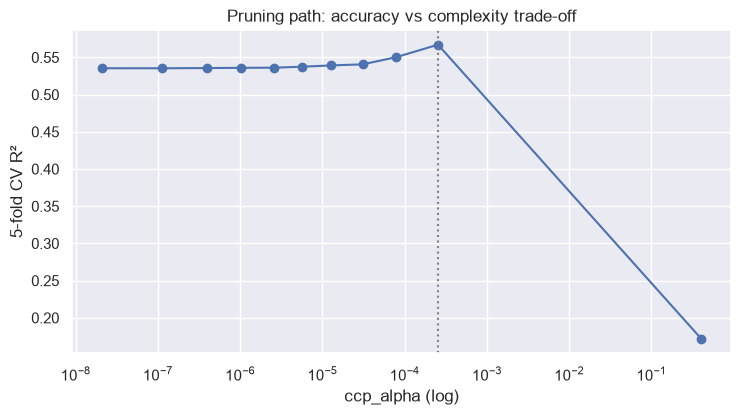

In [5]:
full_tree = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)        # branch-cutting thresholds
alphas = path.ccp_alphas                                               # ascending penalties
grid_idx = np.unique(np.linspace(0, len(alphas) - 1, 12).astype(int))  # 12 evenly spaced stops
alpha_grid = alphas[grid_idx]                                          # affordable CV grid

cv_scores = []
for a in alpha_grid:                                                   # honest audition per alpha
    dt = DecisionTreeRegressor(ccp_alpha=a, random_state=42)
    cv_scores.append(cross_val_score(dt, X_train, y_train, cv=5, scoring="r2").mean())
cv_scores = np.array(cv_scores)

best_alpha = float(alpha_grid[int(np.argmax(cv_scores))])              # penalty with best CV R²
pruned = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42).fit(X_train, y_train)

print(f"best ccp_alpha : {best_alpha:.6f}   CV R²={cv_scores.max():.3f}")
print(f"pruned leaves  : {pruned.get_n_leaves()}   "
      f"test R²={pruned.score(X_test, y_test):.3f}")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.semilogx(alpha_grid[1:], cv_scores[1:], "o-")                       # skip α≈0 for log axis
ax.axvline(best_alpha, ls=":", c="gray")                               # mark CV optimum
ax.set(xlabel="ccp_alpha (log)", ylabel="5-fold CV R²",
       title="Pruning path: accuracy vs complexity trade-off")
plt.show()

### Where does the pruned tree sit?

Add it to the audit table and plot its test scatter next to depth=3's.

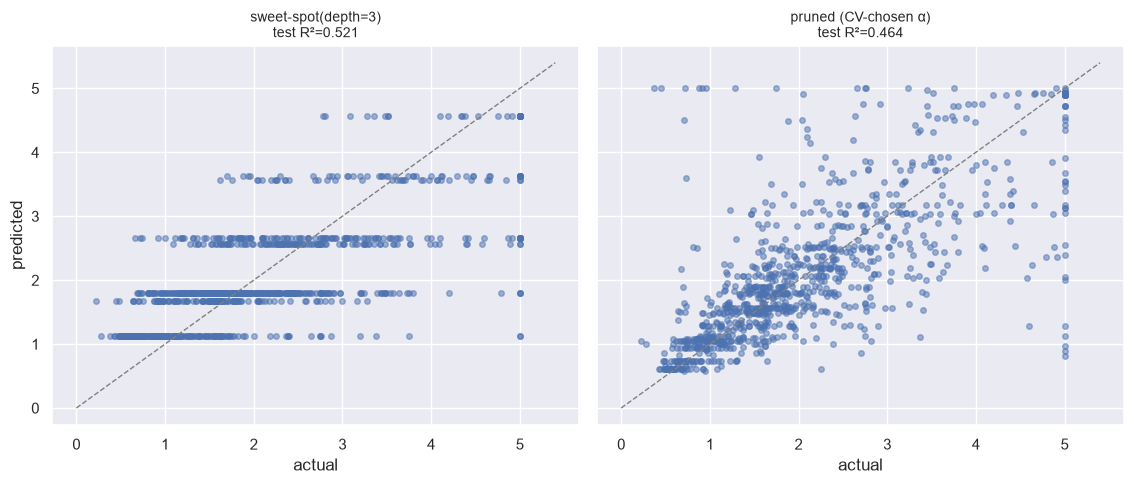

R2   RMSE  leaves
model               split                      
underfit  (depth=1) train  0.307  0.953       2
                    test   0.283  0.984       2
sweet-spot(depth=3) train  0.542  0.775       8
                    test   0.521  0.805       8
overfit   (None)    train  1.000  0.000    3875
                    test   0.441  0.869    3875
pruned  (α=0.0003)  train  0.934  0.293     434
                    test   0.464  0.851     434

In [6]:
rows.append({                                                          # append pruned results
    "model": f"pruned  (α={best_alpha:.4f})", "split": "train",
    "R2": r2_score(y_train, pruned.predict(X_train)),
    "RMSE": np.sqrt(mean_squared_error(y_train, pruned.predict(X_train))),
    "leaves": pruned.get_n_leaves(),
})
rows.append({
    "model": f"pruned  (α={best_alpha:.4f})", "split": "test ",
    "R2": r2_score(y_test, pruned.predict(X_test)),
    "RMSE": np.sqrt(mean_squared_error(y_test, pruned.predict(X_test))),
    "leaves": pruned.get_n_leaves(),
})

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), sharey=True, sharex=True)
for ax, (label, mdl) in zip(axes, [("sweet-spot(depth=3)", fitted["sweet-spot(depth=3)"]),
                                   ("pruned (CV-chosen α)", pruned)]):
    preds = mdl.predict(X_test)
    ax.scatter(y_test, preds, s=16, alpha=0.5)
    ax.plot([0, 5.4], [0, 5.4], ls="--", c="gray", lw=1)               # y=x reference
    ax.set_title(f"{label}\ntest R²={r2_score(y_test, preds):.3f}", fontsize=10)
    ax.set_xlabel("actual")
axes[0].set_ylabel("predicted")
plt.tight_layout(); plt.show()

pd.DataFrame(rows).set_index(["model", "split"]).round(3)              # final four-way table

### The story (read this twice)

**Underfit (depth=1).** One question → two flat predictions. Train R² ≈ test
R² because the model is equally crude everywhere: *high bias, low variance*.
No amount of extra data helps; capacity must grow.

**Overfit (unpruned).** Thousands of leaves chase every quirk, including
noise. Train R² ≈ 1.0 while test lags far behind: *low bias, high variance*.
The gap between the two numbers IS the overfitting measurement.

**Balanced (depth≈3 or CV-pruned α).** Both scores are decent AND close;
predictions track the diagonal without hugging training points. Pruning finds
this region automatically by trading a sliver of fit for a large cut in complexity.

⚠️ Diagnosis rule of thumb:
- both scores low & close → underfit → increase capacity;
- train high / test low → overfit → prune, regularise, or get more data;
- both decent & close → ship it (after checking residuals).

💡 A single tree sits on a knife edge between these states - which is exactly
why random forests (next chapter) average many slightly-different trees.

### Summary & key takeaways

- Capacity ladder demonstrated empirically: depth=1 underfits, None overfits,
  moderate depth / CV-pruned alpha generalises best.
- Train-vs-test R² pairs are the fastest bias-variance diagnostic you have.
- Actual-vs-predicted scatter makes failure modes *visible*: banding (bias)
  vs vertical spray (variance).
- Cost-complexity pruning automates the sweet-spot search using only training
  data + cross-validation - no test-set peeking anywhere in this pipeline.